# Introduction: Using the Kalman filter for smoothing
The output from this notebook will be used to provide answers for this lesson's practice
quiz. It shows how to extend a Kalman filter to smooth past state estimates.

In [2]:
% Place your cursor in this input code cell. Then, type < shift >< enter > to execute

% Data file contains Ad Bd Cd Dd SigmaV SigmaW dT t u x z
load readonly/simOut.mat

rms = @(x) sqrt(mean((x).^2)); % define root-mean-squared function

### Implementing a Kalman filter for the smoothing application
The next notebook cells implement the standard Kalman filter, augmented with steps that compute adjustments to smooth past state estimates of the system.

In [3]:
% Initialize simulation variables
[nx,nt] = size(x); 

xhat = zeros(nx,1);     % Initialize Kalman filter initial estimate
SigmaX = zeros(nx,nx);  % Initialize Kalman filter covariance (part a)

% Reserve storage for variables we might want to plot/evaluate
xhatstore = zeros(nx,nt);
boundstore = xhatstore;
xhatMstore = zeros(nx,nt);
SigmaXstore = zeros(nx,nx,nt);
SigmaXMstore = zeros(nx,nx,nt);
xhatstore(:,1) = xhat;
xhatMstore(:,1) = xhat;
SigmaXstore(:,:,1) = SigmaX;
SigmaXMstore(:,:,1) = SigmaX;

In [4]:
% Implement the forward pass -- a standard Kalman filter
for k = 2:nt
  % KF Step 1a: State prediction time update      
  xhat = Ad*xhat + Bd*u(:,k-1); % use prior value of "u"

  % KF Step 1b: Prediction-error covariance time update
  SigmaX = Ad*SigmaX*Ad' + SigmaW;

  % Store prediction data for smoothing
  xhatMstore(:,k) = xhat;
  SigmaXMstore(:,:,k) = SigmaX;

  % KF Step 1c: Estimate system output
  zhat = Cd*xhat + Dd*u(k);

  % KF Step 2a: Compute Kalman gain matrix
  L = SigmaX*Cd'/(Cd*SigmaX*Cd' + SigmaV);

  % KF Step 2b: State estimate measurement update
  xhat = xhat + L*(z(k) - zhat);

  % KF Step 2c: Estimation-error covariance measurement update
  SigmaX = SigmaX - L*Cd*SigmaX;

  % Store estimate data for smoothing and KF output
  SigmaXstore(:,:,k) = SigmaX;
  xhatstore(:,k) = xhat;
  boundstore(:,k) = 3*sqrt(diag(SigmaX));
end

In [5]:
% Now, do the backward pass to smooth the state estimate ...
xhatSstore = xhatstore;      % smoothed estimate
boundSstore = boundstore;    % smoothed bounds
SigmaXSstore = SigmaXstore;  % smoothed covariance
for k = nt-1:-1:1
  Sp = SigmaXstore(:,:,k);   Sm = SigmaXMstore(:,:,k+1);
  lambda = Sp*Ad'/Sm;
  xhatSstore(:,k) = xhatstore(:,k) + ...
    lambda*(xhatSstore(:,k+1) - xhatMstore(:,k+1));
  Spp = SigmaXSstore(:,:,k+1);
  Sp = Sp + lambda*(Spp - Sm)*lambda';
  SigmaXSstore(:,:,k) = Sp;
  boundSstore(:,k) = 3*sqrt(diag(Sp));
end

### Plot simulation outputs 
The next notebook cells plot the standard Kalman filter's state-vector estimates and smoothed estimates and the estimation errors and smoothed-estimate errors (with bounds).

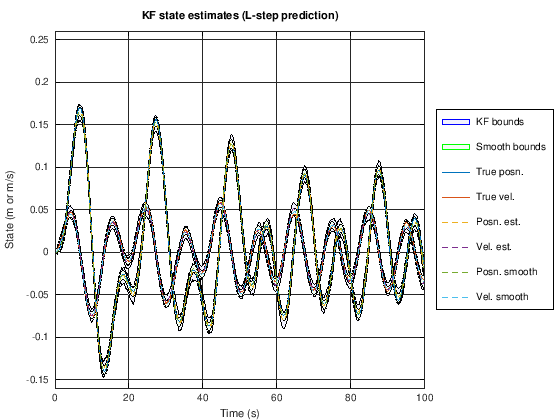

In [6]:
t2 = [t fliplr(t)]; % Prepare for plotting bounds via "fill"
x2 = [xhatstore-boundstore fliplr(xhatstore+boundstore)];
x3 = [xhatSstore-boundSstore fliplr(xhatSstore+boundSstore)];
h1a = fill(t2,x2(1,:),'b',"FaceAlpha",0.05); hold on; grid on
h1b = fill(t2,x2(2,:),'b',"FaceAlpha",0.05); hold on; grid on
h3a = fill(t2,x3(1,:),'g',"FaceAlpha",0.05); hold on; grid on
h3b = fill(t2,x3(2,:),'g',"FaceAlpha",0.05); hold on; grid on
h2 = plot(t,x(1:2,:)',t,xhatstore(1:2,:)','--'); 
h4 = plot(t,xhatSstore(1:2,:)','--'); ylim([-0.16 0.26]);
legend([h2;h4;h1a;h3a],{'True posn.','True vel.','Posn. est.',...
  'Vel. est.','Posn. smooth','Vel. smooth','KF bounds','Smooth bounds'},'Location','EastOutside');
title('KF state estimates (L-step prediction)'); 
xlabel('Time (s)'); ylabel('State (m or m/s)'); 

bndErrFrac1 = 0
rmseEst1 =  0.0030176
rmseSmooth1 =  0.0019528
bndErrFrac2 = 0
rmseEst2 =  0.0023656
rmseSmooth2 =  0.0013865


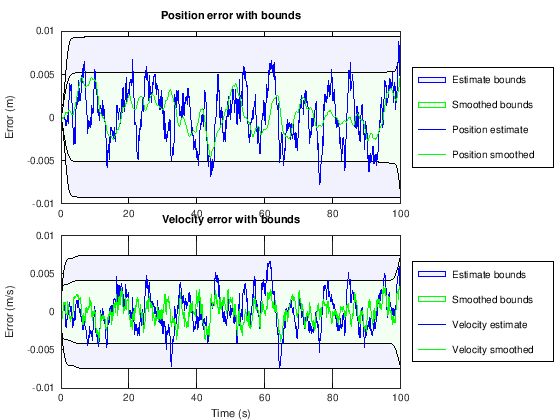

In [7]:
xerr = x - xhatstore; xSerr = x - xhatSstore;
subplot(2,1,1); 
h2 = fill([t fliplr(t)],[-boundstore(1,:) fliplr(boundstore(1,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
h1 = fill([t fliplr(t)],[-boundSstore(1,:) fliplr(boundSstore(1,:))],'g',...
  "FaceAlpha",0.05); 
h3 = plot(t,xerr(1,:),'b',t,xSerr(1,:),'g');
title('Position error with bounds'); ylabel('Error (m)'); 
bndErrFrac1 = length(find(abs(xSerr(1,:))>boundSstore(1,:)))/nt*100
rmseEst1 = rms(xerr(1,:))
rmseSmooth1 = rms(xSerr(1,:))
legend([h1;h2;h3],{'Smoothed bounds','Estimate bounds','Position estimate','Position smoothed'},'Location','EastOutside')

subplot(2,1,2); 
h2 = fill([t fliplr(t)],[-boundstore(2,:) fliplr(boundstore(2,:))],'b',...
  "FaceAlpha",0.05); hold on; grid on;
h1 = fill([t fliplr(t)],[-boundSstore(2,:) fliplr(boundSstore(2,:))],'g',...
  "FaceAlpha",0.05); 
h3 = plot(t,xerr(2,:),'b',t,xSerr(2,:),'g');
ht = title('Velocity error with bounds'); 
hx = xlabel('Time (s)'); ylabel('Error (m/s)'); 
bndErrFrac2 = length(find(abs(xSerr(2,:))>boundSstore(2,:)))/nt*100
rmseEst2 = rms(xerr(2,:))
rmseSmooth2 = rms(xSerr(2,:))
legend([h1;h2;h3],{'Smoothed bounds','Estimate bounds','Velocity estimate','Velocity smoothed'},'Location','EastOutside')